<a href="https://colab.research.google.com/github/carolineolvs/ProvaIcoma/blob/main/prova_34_caroline_silva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Prova 34: ANATEL | Reclamações de Serviços de Telecomunicações:
Consumo: Dados agrupados por motivo de atendimento.

Alvo ( Y ): Corte_Indevido se a reclamação for originada de interrupção ou bloqueio do serviço.
Desafio: Trabalhar com mineração básica de texto (string matching) na coluna de "Motivo" para categorizar a variável alvo.

# Aluno: Caroline Oliveira Silva

## Importar Drive


In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Bibliotecas


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import textwrap
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

## Carregar base de dados


In [22]:
df = pd.read_csv('/content/drive/MyDrive/provaicoma/reclamacoes_contexto.csv', sep=';')

df.head()

,DataExtracao,SOLICITAÇÕES,Ano,Mês,AnoMês,UF,Cidade,CO_MUNICIPIO,CanalEntrada,Condição,TipoAtendimento,Serviço,Marca,Assunto,Problema,Linha
0,10/01/2025,1,2020,10,2020-10,SP,São Paulo,3550308,Usuário web,Nova,Reclamação,SMP_Pré,VIVO,Dados cadastrais ou número da linha,Perda de número da linha,1
1,10/01/2025,1,2020,8,2020-08,PR,Arapongas,4101507,Call center,Nova,Reclamação,STFC,VIVO,Cobrança,Cobrança em desacordo com o contratado,2
2,10/01/2025,2,2020,9,2020-09,SP,São Paulo,3550308,Mobile app,Nova,Reclamação,SMP_Pós,VIVO,Instalação ou ativação ou habilitação,Instalação ou habilitação não realizada,3
3,10/01/2025,1,2020,8,2020-08,RN,Mossoró,2408003,Mobile app,Nova,Reclamação,SCM,TCM TV CABO MOSSORO,Cobrança,Cobrança indevida de multa por fidelização (mu...,4
4,10/01/2025,1,2020,11,2020-11,AL,Maceió,2704302,Usuário web,Nova,Reclamação,SCM,CLARO,Instalação ou ativação ou habilitação,Instalação ou habilitação não realizada,5


In [23]:
print(f"Total de Linhas e Colunas: {df.shape}")

Total de Linhas e Colunas: (1048575, 16)


In [24]:
termos_chave = [
    'bloqueio', 'bloqueado', 'suspensão', 'suspenso', 'suspens',
    'interrupção', 'interrompido', 'sem sinal', 'linha muda',
    'sem conexão', 'sem imagem', 'indisponível',
    'desligado', 'desativado', 'cortado', 'corte'
]

In [25]:
padrao_busca = '|'.join(termos_chave)

In [26]:
df['Corte_Indevido'] = (
    df['Assunto'].str.contains(padrao_busca, case=False, na=False) |
    df['Problema'].str.contains(padrao_busca, case=False, na=False)
).astype(int)

In [27]:
df = df.dropna(subset=['Assunto', 'Problema'])
vectorizer = TfidfVectorizer(max_features=100, stop_words=None)
X_tfidf = vectorizer.fit_transform(df['Problema']).toarray()

scaler = StandardScaler()
X_final = scaler.fit_transform(X_tfidf)
y = df['Corte_Indevido']

Text(0, 0.5, 'Quantidade')

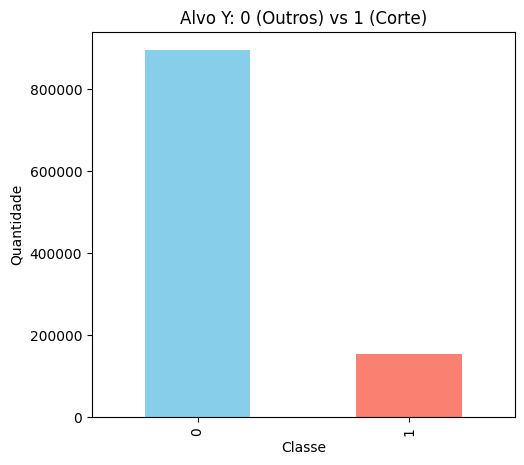

In [28]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df['Corte_Indevido'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Alvo Y: 0 (Outros) vs 1 (Corte)')
plt.xlabel('Classe')
plt.ylabel('Quantidade')


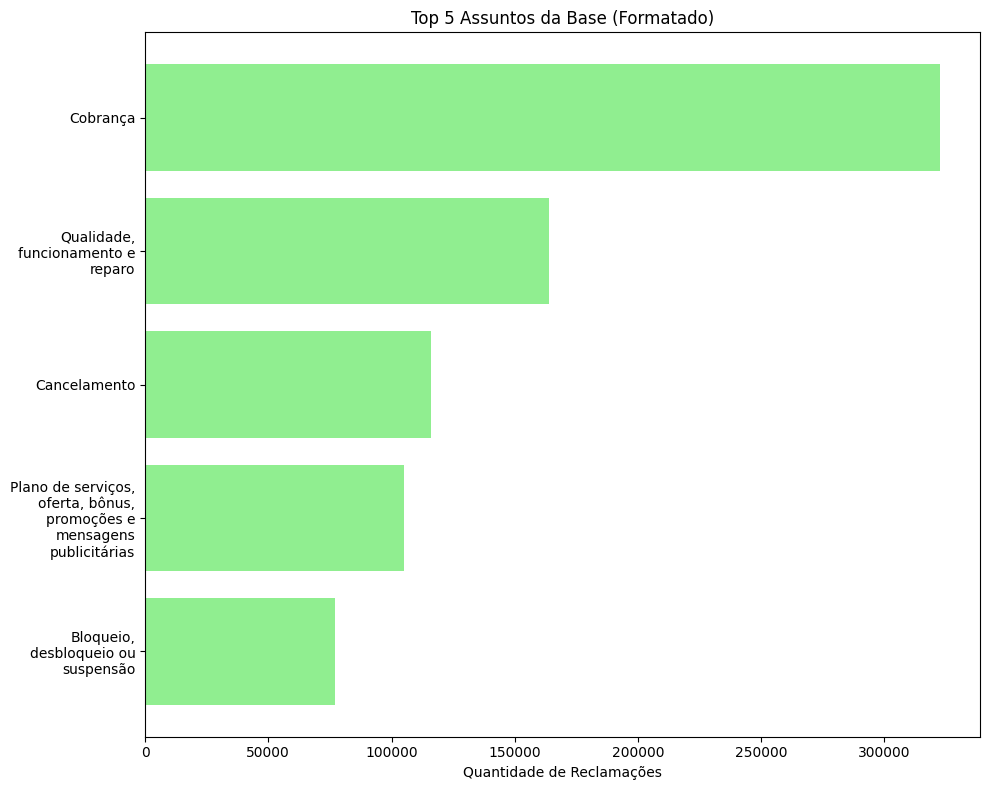

In [37]:
# 1. Preparando os dados
contagem = df['Assunto'].value_counts().head(5).sort_values(ascending=True)

# 2. Criando os nomes "quebrados" para o eixo Y
# Aqui definimos que cada linha terá no máximo 20 caracteres
nomes_quebrados = [textwrap.fill(assunto, width=20) for assunto in contagem.index]

# 3. Plotando
plt.figure(figsize=(10, 8))
plt.barh(nomes_quebrados, contagem, color='lightgreen')

plt.title('Top 5 Assuntos da Base (Formatado)')
plt.xlabel('Quantidade de Reclamações')
plt.tight_layout()
plt.show()

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)


In [31]:
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [32]:
y_pred = model.predict(X_test)
print("Acurácia:", accuracy_score(y_test, y_pred))

Acurácia: 0.9300097751710655


In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.92      0.96    178770
           1       0.68      1.00      0.81     30945

    accuracy                           0.93    209715
   macro avg       0.84      0.96      0.88    209715
weighted avg       0.95      0.93      0.94    209715



In [34]:

assuntos_unicos = df['Assunto'].unique()

problemas_unicos = df['Problema'].unique()

print("--- LISTA DE ASSUNTOS (SEM REPETIÇÃO) ---")
for i, assunto in enumerate(assuntos_unicos, 1):
    print(f"{i}. {assunto}")

print("\n--- LISTA DE PROBLEMAS (SEM REPETIÇÃO) ---")
for i, problema in enumerate(problemas_unicos, 1):
    print(f"{i}. {problema}")

--- LISTA DE ASSUNTOS (SEM REPETIÇÃO) ---
1. Dados cadastrais ou número da linha
2. Cobrança
3. Instalação ou ativação ou habilitação
4. Qualidade, funcionamento e reparo
5. Plano de serviços, oferta, bônus, promoções e mensagens publicitárias
6. Ressarcimento
7. Cancelamento
8. Autorização / licença / outorga
9. Banda larga fixa (scm)
10. Sistema anatel consumidor
11. Atendimento
12. Mudança de endereço
13. Bloqueio, desbloqueio ou suspensão
14. Atuação anatel
15. Crédito pré-pago
16. Portabilidade
17. Certificação e homologação de produtos (equipamento) de telecomunicações
18. Canais de relacionamento
19. Recebimento inoportuno de ligações de oferta
20. Regulamentação
21. Móvel pessoal (smp)
22. Outorga
23. Não consegue bloquear/desbloquear o aparelho
24. Solicitação de vista de processo ou documento
25. Rádio fm
26. Certificação / homologação de produto (fabricação, comercialização ou utilização)
27. Fiscalização
28. Lei geral de proteção de dados
29. Serviço limitado privado (slp)
